In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)
from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

In [2]:
df=pd.read_csv("Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39.0,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35.0,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36.0,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1,0,92888.52,1


In [3]:
df['Age']= df['Age'].fillna(df['Age'].median())
df['Gender']= df['Gender'].fillna(df['Gender'].mode()[0])
print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Exited
0    7963
1    2037
Name: count, dtype: int64


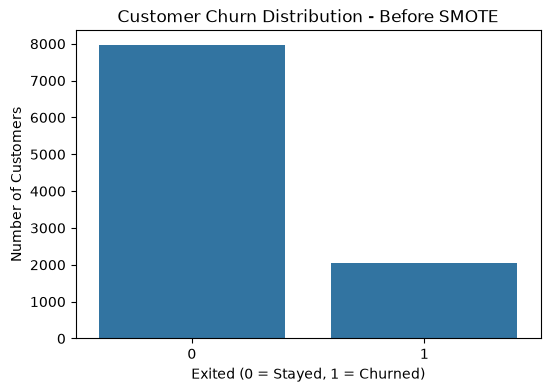

In [4]:
print(df['Exited'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title("Customer Churn Distribution - Before SMOTE")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.show()

In [5]:
X = df.drop(
columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'],
)
y = df['Exited']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10)
y shape: (10000,)


In [6]:
X = pd.get_dummies(
X,
columns=['Geography', 'Gender'],
drop_first=True
)
print("Shape after One-Hot Encoding:", X.shape)
X.head()

Shape after One-Hot Encoding: (10000, 11)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42.0,2,0.00,1,1,1,101348.88,False,False,False
1,608,41.0,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42.0,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39.0,1,0.00,2,0,0,93826.63,False,False,False
4,850,43.0,2,125510.82,1,1,1,79084.10,False,True,False


In [7]:
X_train, X_test, y_train, y_test= train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())

Training data: (8000, 11)
Testing data : (2000, 11)

Training class distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)
print("Training data scaled.")
print("Testing data scaled.")

Training data scaled.
Testing data scaled.


In [9]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_balanced, y_train_balanced= smote.fit_resample(
X_train_scaled,
y_train
)

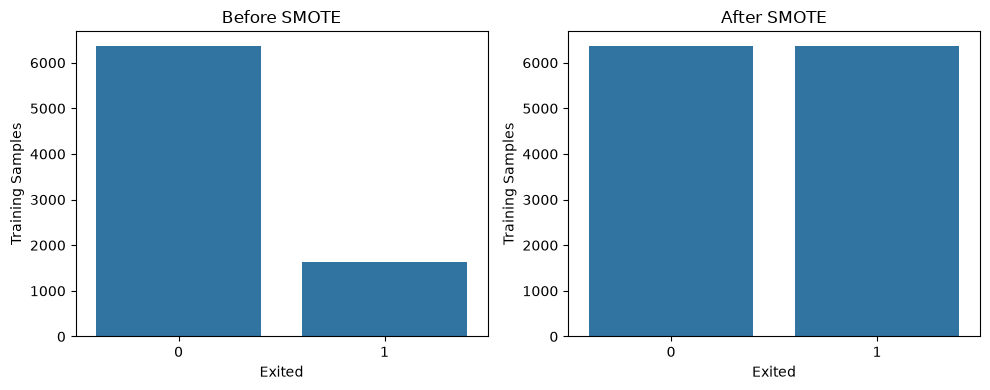

In [10]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
sns.countplot(x=y_train,ax=axes[0])
sns.countplot(x=y_train_balanced,ax=axes[1])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Exited")
axes[0].set_ylabel("Training Samples")
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Exited")
axes[1].set_ylabel("Training Samples")
plt.tight_layout()
plt.show()

In [13]:
nb_model=GaussianNB()
nb_model.fit(X_train_balanced,y_train_balanced)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[6370.,6370.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.227e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 11)","[[ 0.02,-0.14, 0. ,...,-0.09, 0.03, 0.05], [-0.04, 0.56, 0. ,..., 0.37,-0.11,-0.19]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 11)","[[0.98,0.93,0.99,...,0.89,1.03,0.99], [0.92,0.73,0.94,...,1.29,0.86,0.99]]"


In [14]:
y_pred= nb_model.predict(X_test_scaled)
print("First 20 predictions:")
print(y_pred[:20])
print("\nFirst 20 actual values:")
print(y_test.values[:20])

First 20 predictions:
[0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1]

First 20 actual values:
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0]


In [15]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7135
Precision: 0.3850415512465374
Recall : 0.683046683046683
F1 Score : 0.4924712134632418

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.68      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.79      0.71      0.74      2000



[[1149  444]
 [ 129  278]]


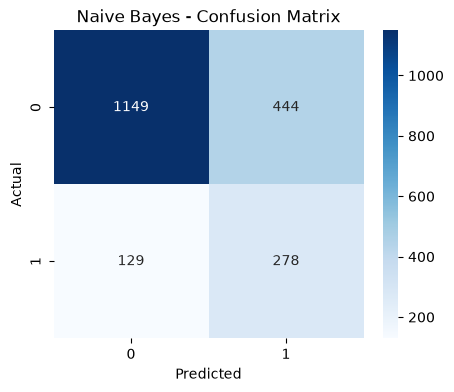

In [16]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [17]:
nb_baseline=GaussianNB()
nb_baseline.fit(X_train_scaled,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[6370.,1630.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.8,0.2]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 11)","[[ 0.02,-0.14, 0. ,...,-0.09, 0.03, 0.05], [-0.07, 0.55,-0. ,..., 0.36,-0.11,-0.21]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 11)","[[0.98,0.93,0.99,...,0.89,1.03,0.99], [1.08,0.87,1.05,...,1.28,0.86,1. ]]"


In [18]:
y_pred_baseline=nb_baseline.predict(X_test_scaled)
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1593
           1       0.60      0.35      0.44       407

    accuracy                           0.82      2000
   macro avg       0.72      0.64      0.67      2000
weighted avg       0.80      0.82      0.80      2000



In [19]:
comparison= pd.DataFrame({
'Model': [
'Naive Bayes - Before SMOTE',
'Naive Bayes - After SMOTE'
],
'Accuracy': [
accuracy_score(y_test, y_pred_baseline),
accuracy_score(y_test, y_pred)
],
'Precision (Churn)': [
precision_score(y_test, y_pred_baseline),
precision_score(y_test, y_pred)
],
'Recall (Churn)': [
recall_score(y_test, y_pred_baseline),
recall_score(y_test, y_pred)
],
'F1 (Churn)': [
f1_score(y_test, y_pred_baseline),
f1_score(y_test, y_pred)
]
})


In [20]:
comparison


,Model,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn)
0,Naive Bayes - Before SMOTE,0.8200,0.600000,0.346437,0.439252
1,Naive Bayes - After SMOTE,0.7135,0.385042,0.683047,0.492471


In [1]:
from sklearn.pipeline import Pipeline


In [31]:
navi_pipeline= Pipeline([
('scaler', StandardScaler()),
('scaler':SMOTE),
('svm', GaussianNB())
])
gsc=GridSearchCV(
    estimator=navi_pipeline,
    param_grid={
        'smote__ratio':np.linspace(0.005,0.25,10)
    },
    scoring='f1',

    cv=3
)


SyntaxError: invalid syntax (1123202172.py, line 3)

In [28]:
navi_pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['CreditScore','Age','Tenure',...,'Geography_Germany','Geography_Spain', 'Gender_Male']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
